# 03 — Modelagem

Três classificadores são treinados e comparados: Regressão Logística, Random Forest
e Gradient Boosting.

In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

sys.path.append(str(Path("..").resolve()))
from src.config import (
    RANDOM_STATE, DATA_RAW, DATA_PROCESSED, RESULTS, FIGURES, METRICS, MODELS,
    RAW_FILE, PROCESSED_FILE, ID_COL, TARGET, TARGET_BIN, QUALITY_THRESHOLD,
    TEST_SIZE, CV_FOLDS,
)

pd.set_option("display.max_columns", None)
sns.set_theme(style="whitegrid")
plt.rcParams["figure.dpi"] = 100
from src.models import get_models

In [2]:
df = pd.read_csv(PROCESSED_FILE)
df.shape

(1143, 15)

## 1. Split treino/teste

O parâmetro `stratify` preserva a proporção das classes em ambos os conjuntos —
procedimento essencial diante de uma variável resposta desbalanceada (~14% de
positivos), sob pena de o conjunto de teste concentrar um número reduzido de
observações da classe minoritária, ou mesmo nenhuma.

In [3]:
from sklearn.model_selection import train_test_split

# 'quality' é a nota original, usada só para derivar 'quality_bin' — mantê-la em X
# vazaria a resposta (ver aviso no fim do notebook 02).
drop_cols = [TARGET, TARGET_BIN]
X = df.drop(columns=drop_cols)
y = df[TARGET_BIN]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=TEST_SIZE, stratify=y, random_state=RANDOM_STATE
)
print("X_train:", X_train.shape, " X_test:", X_test.shape)
print("proporção de positivos — treino:", round(y_train.mean(), 4),
      " teste:", round(y_test.mean(), 4))

X_train: (914, 13)  X_test: (229, 13)
proporção de positivos — treino: 0.1389  teste: 0.1397


**Leitura:** o `stratify=y` funcionou como esperado — a proporção de vinhos de alta
qualidade fica em ~13,9% tanto no treino quanto no teste, praticamente idêntica à
proporção original de 13,91% (notebook 01, seção 5). Sem estratificação, um split
aleatório poderia facilmente concentrar boa parte dos 159 exemplos positivos em um dos
dois conjuntos, distorcendo tanto o treino quanto a avaliação.

## 2. Modelos candidatos

Usar `Pipeline` evita vazamento: o scaler é ajustado só no fold de treino durante a
validação cruzada. Os três modelos usam `random_state=RANDOM_STATE` e, quando o
classificador suporta, `class_weight="balanced"` — necessário porque o alvo tem só
~14% de exemplos positivos (ver `src/models.py` para a definição completa).

In [4]:
modelos = get_models()
list(modelos.keys())

['logistic_regression', 'random_forest', 'gradient_boosting']

- **`logistic_regression`** — baseline linear e interpretável (coeficientes viram
  "importância de variável" no notebook 04). `class_weight="balanced"`.
- **`random_forest`** — ensemble de árvores, captura relações não-lineares e interações
  sem precisar de escala. `class_weight="balanced"`.
- **`gradient_boosting`** — boosting sequencial, geralmente mais preciso que uma única
  árvore/floresta em bases pequenas como esta, ao custo de mais tempo de treino.
  `GradientBoostingClassifier` do scikit-learn não expõe `class_weight`, então o
  desbalanceamento é compensado apenas pelo split estratificado e pela escolha de F1
  (não acurácia) como métrica de seleção.

## 3. Validação cruzada

5-fold estratificado (`StratifiedKFold`) no conjunto de **treino apenas** — o teste fica
intocado até o notebook 04, para dar uma estimativa final sem qualquer influência das
escolhas feitas aqui.

In [5]:
from sklearn.model_selection import StratifiedKFold, cross_val_score

cv = StratifiedKFold(n_splits=CV_FOLDS, shuffle=True, random_state=RANDOM_STATE)

cv_scores = {}
for nome, modelo in modelos.items():
    scores = cross_val_score(modelo, X_train, y_train, cv=cv, scoring="f1")
    cv_scores[nome] = scores
    print(f"{nome:20s} F1 = {scores.mean():.4f} +/- {scores.std():.4f}")

logistic_regression  F1 = 0.5103 +/- 0.0584


random_forest        F1 = 0.6112 +/- 0.0583


gradient_boosting    F1 = 0.6038 +/- 0.1140


## 4. Comparação

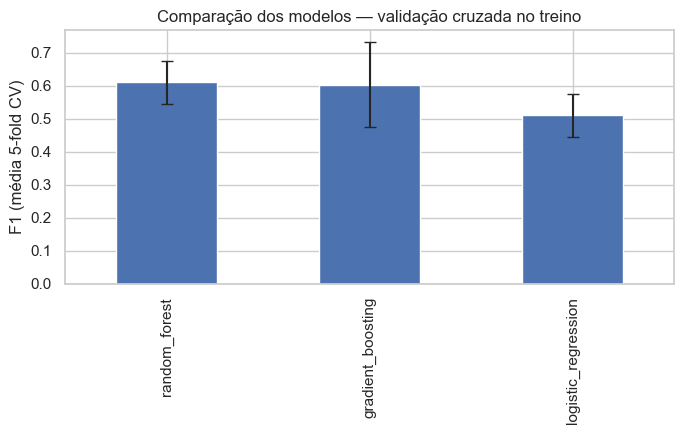

random_forest          0.6112
gradient_boosting      0.6038
logistic_regression    0.5103
dtype: float64

In [6]:
cv_df = pd.DataFrame(cv_scores)
fig, ax = plt.subplots(figsize=(7, 4.5))
cv_df.mean().sort_values(ascending=False).plot.bar(
    yerr=cv_df.std(), ax=ax, color="#4C72B0", capsize=4
)
ax.set_ylabel("F1 (média 5-fold CV)")
ax.set_title("Comparação dos modelos — validação cruzada no treino")
fig.tight_layout()
fig.savefig(FIGURES / "05_cv_comparacao.png", dpi=150, bbox_inches="tight")
plt.show()

cv_df.mean().sort_values(ascending=False).round(4)

**Leitura:** `random_forest` (F1 médio ≈ 0,61) e `gradient_boosting` (≈ 0,60) ficam
praticamente empatados na validação cruzada — a diferença entre eles (≈ 0,01) é bem
menor que o desvio-padrão de cada um (≈ 0,06 e ≈ 0,11), ou seja, está dentro do ruído
entre folds, não é uma vitória clara de um sobre o outro nesta etapa. `logistic_regression`
fica visivelmente atrás (F1 ≈ 0,51): sendo um modelo linear, tem mais dificuldade para
capturar as relações não-lineares e interações entre variáveis físico-químicas que os
dois ensembles de árvore conseguem representar. O desempate entre Random Forest e
Gradient Boosting só é feito com a métrica final, no conjunto de teste (notebook 04).

## 5. Treino final e persistência

Cada modelo é reajustado em **todo** o conjunto de treino (não apenas nos folds da CV)
e salvo em `results/models/` — os arquivos `.joblib` não são versionados no Git
(`*.joblib` está no `.gitignore`), porque são inteiramente reproduzíveis rodando este
notebook.

In [7]:
import joblib

MODELS.mkdir(parents=True, exist_ok=True)
for nome, modelo in modelos.items():
    modelo.fit(X_train, y_train)
    joblib.dump(modelo, MODELS / f"{nome}.joblib")

print("Modelos treinados e salvos em:", MODELS)
list(MODELS.glob("*.joblib"))

Modelos treinados e salvos em: C:\Users\Felipe\OneDrive\Área de Trabalho\TECHCHALLENGE_FASE2\wine-quality-classification\results\models


[WindowsPath('C:/Users/Felipe/OneDrive/Área de Trabalho/TECHCHALLENGE_FASE2/wine-quality-classification/results/models/gradient_boosting.joblib'),
 WindowsPath('C:/Users/Felipe/OneDrive/Área de Trabalho/TECHCHALLENGE_FASE2/wine-quality-classification/results/models/logistic_regression.joblib'),
 WindowsPath('C:/Users/Felipe/OneDrive/Área de Trabalho/TECHCHALLENGE_FASE2/wine-quality-classification/results/models/random_forest.joblib')]